# Decision Trees Classifier

Design a ML model that would predict the label (setosa, virginica, versicolor) of a iris flower data (sepal_length, sepal_width, petal_length, petal_width).

Here the features can be numerical or categorical

You have a training data given to you of Iris flower.

Steps:
```
   --> Collect data 
   --> Split into training + testing
   --> Feed training data to model (i.e. train the model) 
   --> Evaluate the model by feeding testing data
```

In [1]:
# Data collection: load the data
import pandas as pd

df = pd.read_csv("data_iris.csv")
print(df.head(5))

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [2]:
# lets find the size
print(df.shape) # rows, col 

(150, 5)


In [3]:
# Label encoding and data split ( Train + Test )
# step1: Separate features(X) and labels(y):

# X = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
# y = df["species"]

# Use following when you have many columns
X = df.drop(columns=['species']) # X = all columns except the target
y = df['species']

print("X:\n", X)
print("y:\n", y)

X:
      sepal_length  sepal_width  petal_length  petal_width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]
y:
 0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object


In [4]:
# step3: Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,# 30% of the data is used for testing
                                                    random_state=42,# random_state ensures reproducibility of the split
                                                    shuffle=True)

In [5]:
print("Shape of training dataset:", X_train.shape) # 105 rows and 4 columns
print("Shape of testing dataset:", X_test.shape) # 105 rows and 4 columns

Shape of training dataset: (105, 4)
Shape of testing dataset: (45, 4)


In [6]:
# Now lets make sure that you have balanced target variable in training data
import numpy as np

values, counts = np.unique(y_train, return_counts=True)
value_counts = dict(zip(values, counts))

print("Value counts for training data:", value_counts)

Value counts for training data: {'setosa': 31, 'versicolor': 37, 'virginica': 37}


In [7]:
# Modeling + Training: I am picking Decision Tree model
from sklearn.tree import DecisionTreeClassifier

# max_depth: The length of the longest path from a root node to a leaf node will not exceed this value.
# This is the most commonly tuned hyperparameter for tree-based method. Here I will uses default value
model = DecisionTreeClassifier(max_depth=2, # Try to change this to 3 and 4 and accuracy would go , but may be overfiting. 
                             random_state=0)

In [8]:
# train the model

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=0)

In [9]:
# Lets print all hyperparam

print(model.get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 2, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 0, 'splitter': 'best'}


In [10]:
# I picked following 3 points from data and checked their prediction:
sample = [
    # sepal_length, sepal_width, petal_length, petal_width
    [5.1, 3.5, 1.4, 0.2],   # actual--> setosa
    [7,   3.2, 4.7, 1.4],   # actual--> versicolor
    [6.3, 3.3, 6,   2.5],   # actual--> virginica
]
          
sample_df  = pd.DataFrame(sample, columns=X.columns)

prediction = model.predict(sample_df)

print("Prediction:", prediction)

Prediction: ['setosa' 'versicolor' 'virginica']


In [11]:
# Make predictions on the test set

y_pred = model.predict(X_test)

In [17]:
# lets print 1st 5 predicted and actual target value

print("predicted:", y_pred[:5])
print("actual   :", list(y_test[:5]))

predicted: ['versicolor' 'setosa' 'virginica' 'versicolor' 'virginica']
actual   : ['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor']


In [19]:
# Lets reprint above in detailed form

results = pd.DataFrame({
    "Actual"   : y_test,
    "Predicted": y_pred,
    "Match"    : (y_test == y_pred).astype(int)   # 1 = correct, 0 = incorrect
})

print(results)

         Actual   Predicted  Match
73   versicolor  versicolor      1
18       setosa      setosa      1
118   virginica   virginica      1
78   versicolor  versicolor      1
76   versicolor   virginica      0
31       setosa      setosa      1
64   versicolor  versicolor      1
141   virginica   virginica      1
68   versicolor  versicolor      1
82   versicolor  versicolor      1
110   virginica   virginica      1
12       setosa      setosa      1
36       setosa      setosa      1
9        setosa      setosa      1
19       setosa      setosa      1
56   versicolor  versicolor      1
104   virginica   virginica      1
69   versicolor  versicolor      1
55   versicolor  versicolor      1
132   virginica   virginica      1
29       setosa      setosa      1
127   virginica   virginica      1
26       setosa      setosa      1
128   virginica   virginica      1
131   virginica   virginica      1
145   virginica   virginica      1
108   virginica   virginica      1
143   virginica   vi

### Accuracy is defined as(fraction of correct predictions)

- correct predictions / total number of data points

In [20]:
# Evaluate the model's performance
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9778


In [21]:
# display the confusion matrix

from sklearn.metrics import accuracy_score, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]


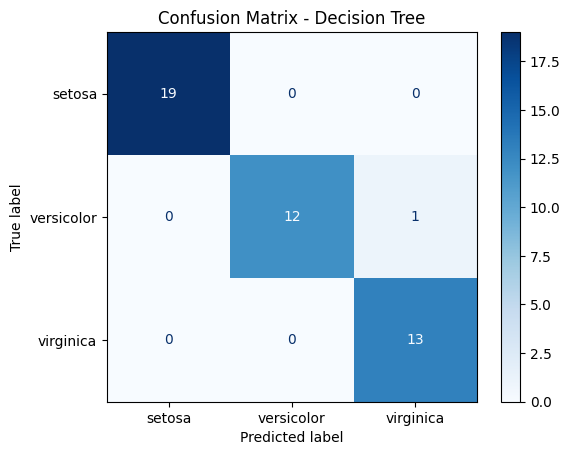

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = model.classes_   # preserves correct order

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

## Visualize Decision Trees using Matplotlib

Decision Trees can now be plotted with matplotlib using scikit-learn's `tree.plot_tree` . 

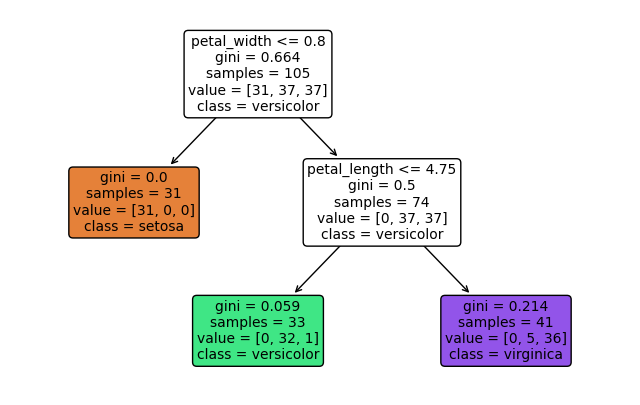

In [17]:
from sklearn.tree import plot_tree

plt.figure(figsize=(8, 5))
plot_tree(
    model,
    filled=True,
    rounded=True,
    feature_names=X.columns,
    class_names=encoder.classes_,
    fontsize=10
)

plt.show()
# fig.savefig('plottreefncn.png') # optional if u want to save 

### Hyperparameter Tuning
The default tree is quite complex, and we need to simplify it by tuning the hyperparameters.

First, let's understand the parameters in a decision tree. You can read this in the documentation using help(DecisionTreeClassifier).

- criterion (Gini/IG or entropy): It defines the function to measure the quality of a split. Sklearn supports “gini” criteria for Gini Index & “entropy” for Information Gain. By default, it takes the value “gini”.
- splitter: It defines the strategy to choose the split at each node. Supports “best” value to choose the best split & “random” to choose the best random split. By default, it takes “best” value.
- max_features: It defines the no. of features to consider when looking for the best split. We can input integer, float, string & None value.
- max_depth: The max_depth parameter denotes maximum depth of the tree. It can take any integer value or None. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples. By default, it takes “None” value.
- min_samples_split: This tells above the minimum no. of samples reqd. to split an internal node. If an integer value is taken then consider min_samples_split as the minimum no. If float, then it shows percentage. By default, it takes “2” value.
- min_samples_leaf: The minimum number of samples required to be at a leaf node. If an integer value is taken then consider - -min_samples_leaf as the minimum no. If float, then it shows percentage. By default, it takes “1” value.
- max_leaf_nodes: It defines the maximum number of possible leaf nodes. If None then it takes an unlimited number of leaf nodes. By default, it takes “None” value.
- min_impurity_split: It defines the threshold for early stopping tree growth. A node will split if its impurity is above the threshold otherwise it is a leaf.

## Grid Search to Find Optimal Hyperparameters
#### We can now use GridSearchCV to find multiple optimal hyperparameters together. Note that this time, we'll also specify the criterion (gini/entropy or IG).

In [18]:
# GridSearchCV to find optimal min_samples_split
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

# Create the parameter grid 
param_grid = {
    'max_depth': range(1, 8, 1),
    'min_samples_leaf': range(1, 10, 2),
    'min_samples_split': range(2, 10, 2),
    'criterion': ["entropy", "gini"]
}

n_folds = 5

# Instantiate the grid search model
iristree = DecisionTreeClassifier()
grid_search = GridSearchCV(estimator = iristree,
                           param_grid = param_grid, 
                           cv = n_folds,
                           verbose = 1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 280 candidates, totalling 1400 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': range(1, 8),
                         'min_samples_leaf': range(1, 10, 2),
                         'min_samples_split': range(2, 10, 2)},
             verbose=1)

In [19]:
# cv results
cv_results = pd.DataFrame(grid_search.cv_results_)
print(cv_results)

     mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0         0.002192  4.040370e-04         0.001641        0.000527   
1         0.001604  4.923720e-04         0.001598        0.000494   
2         0.001985  1.398085e-05         0.001212        0.000417   
3         0.002000  3.162980e-07         0.001400        0.000490   
4         0.001600  4.902909e-04         0.001400        0.000490   
..             ...           ...              ...             ...   
275       0.001801  4.002097e-04         0.001399        0.000490   
276       0.001799  3.993067e-04         0.001601        0.000491   
277       0.001801  4.006636e-04         0.001599        0.000489   
278       0.001798  3.990597e-04         0.001403        0.000492   
279       0.002001  2.906752e-06         0.001401        0.000801   

    param_criterion param_max_depth param_min_samples_leaf  \
0           entropy               1                      1   
1           entropy               1            

In [20]:
# printing the optimal accuracy score and hyperparameters
print("best accuracy", grid_search.best_score_)
print(grid_search.best_estimator_)

best accuracy 0.9428571428571428
DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=5)


### Running the model with best parameters obtained from grid search

In [21]:
# model with optimal hyperparameters
model_best = DecisionTreeClassifier(criterion = "entropy",
                  random_state = 100,
                  max_depth=4, 
                  min_samples_leaf=3,
                  min_samples_split=2
)
model_best.fit(X_train, y_train)

# accuracy score
print(model_best.score(X_test, y_test))

1.0


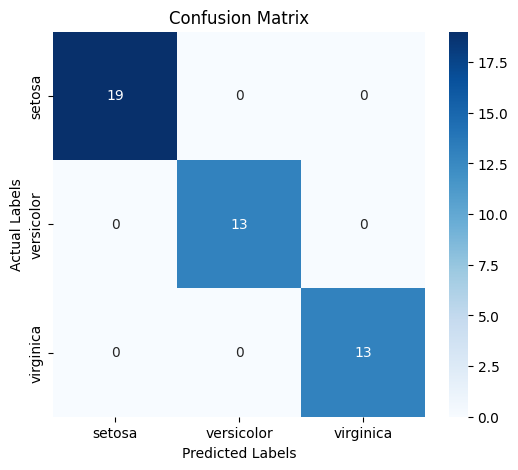

In [22]:
y_pred = model_best.predict(X_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm,
            annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix")
plt.show()

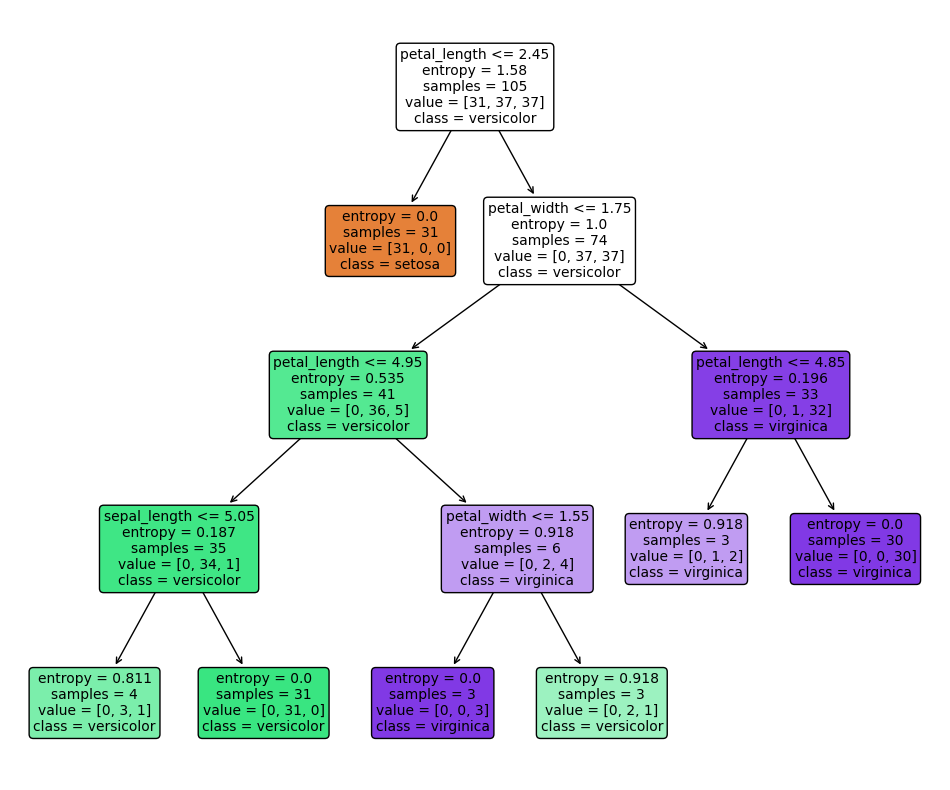

In [24]:
# 1)
plt.figure(figsize=(12, 10))
plot_tree(
    model_best,
    filled=True,
    rounded=True,
    feature_names=X.columns,
    # class_names=encoder.classes_,
    class_names=model.classes_.astype(str),
    fontsize=10
)

plt.show()
# fig.savefig('plottreefncn.png') # optional if u want to save 

In [ ]:
# 2) Lets predict species using above Decision Tree for  
sample = [
    # sepal_length, sepal_width, petal_length, petal_width
    [5.1, 3.5, 1.4, 0.2],   # actual--> setosa
    [7,   3.2, 4.7, 1.4],   # actual--> versicolor
    [6.3, 3.3, 6,   2.5],   # actual--> virginica
]

# I used DT to verify above are predicted correctly

### Better than above. 